# Predicción de Riesgo de Enfermedad Cardíaca

**Contexto**: Contexto introductorio

La enfermedad cardíaca es la principal causa de muerte en el mundo, cobrando aproximadamente 18 millones de vidas cada año, según reporta la Organización Mundial de la Salud. Modelos predictivos como la regresión logística pueden permitir la identificación temprana de pacientes en riesgo mediante el análisis de características clínicas como edad, colesterol y presión arterial. Esto no solo mejora los resultados del tratamiento, sino que también optimiza la asignación de recursos en entornos de atención médica.

En esta tarea, implementarás regresión logística sobre el Heart Disease Dataset (Conjunto de Datos de Enfermedad Cardíaca), una colección real del repositorio UCI con 303 registros de pacientes, 14 características y un objetivo binario: 1 para presencia de enfermedad y 0 para ausencia. Entrenarás modelos, visualizarás fronteras de decisión, aplicarás regularización y usarás Amazon SageMaker para entrenar y probar el modelo en un entorno de nube administrado.


## 1. Exploración de Heart Disease Dataset


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("heart.csv")  

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


*df.info()* nos permite ver la información del dataset. En este caso vemos que hay 14 columnas (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target). También se puede observar que las filas de cada columna están completas y que cada una presenta 1025 valores no nulos.

In [20]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
df[numeric_cols].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.754146
std,9.072290,17.516718,51.59251,23.005724,1.175053,1.030798
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,0.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,4.000000


In [21]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "target"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

df.describe()      
df.describe(include="category")   

,sex,cp,fbs,restecg,exang,slope,thal,target
count,1025,1025,1025,1025,1025,1025,1025,1025
unique,2,4,2,3,2,3,4,2
top,1,0,0,1,0,1,2,1
freq,713,497,872,513,680,482,544,526


In [22]:
hombres = (713 / 1025) * 100
mujeres = ((1025 - 713) / 1025) * 100

print(f"Hombres: {hombres}% \n Mujeres: {mujeres}%")

enfermos = ((526 / 1025)) * 100
no_enfermos= ((1025 - 526) / 1025) * 100

print(f"\nPacientes enfermos: {enfermos}% \n Pacientes sin enfermedad: {no_enfermos}%")

Hombres: 69.5609756097561% 
 Mujeres: 30.4390243902439%

Pacientes enfermos: 51.31707317073171% 
 Pacientes sin enfermedad: 48.68292682926829%


Al aplicar **df.describe()**, se observó que esta función calcula estadísticas (media, desviación estándar, mínimos y máximos) para todas las columnas numéricas, incluyendo aquellas que en realidad son variables categóricas codificadas como enteros (por ejemplo, sex, cp, target). Dado que estas estadísticas no tienen interpretación válida para variables categóricas, se convirtieron dichas columnas (sex, cp, fbs, restecg, exang, slope, thal, target) al tipo *category* mediante **astype("category")**. De esta forma, **df.describe()** calcula estadísticas únicamente sobre las columnas numéricas reales (age, trestbps, chol, thalach, oldpeak, ca), mientras que **df.describe(include="category")** permite obtener un resumen apropiado de las variables categóricas: número de categorías únicas, la categoría más frecuente (moda) y su frecuencia.

**Interpretación para variables numéricas:**

La edad (`age`) de los pacientes va de 29 a 77 años, con una media de 54.4 años. La presión arterial en reposo (`trestbps`) va de 94 a 200, con una media de 131.6. El colesterol (`chol`) va de 126 a 564, con una media de 246; este máximo se aleja bastante del resto de los datos, por lo que podría ser un valor atípico a revisar. La frecuencia cardíaca máxima (`thalach`) va de 71 a 202, con una media de 149. La depresión del segmento ST (`oldpeak`) va de 0 a 6.2, con una media de 1.07; la mayoría de los valores están concentrados en el rango bajo (75% de los datos está por debajo de 1.8). El número de vasos principales (`ca`) va de 0 a 4, con una media de 0.75.

**Interpretación para variables categóricas:**

La mayoría de los pacientes registrados son hombres, con un 69.6% frente a un 30.4% de mujeres. Frente a la variable objetivo (`target`), la distribución está más o menos balanceada: 51.3% de los pacientes presenta enfermedad cardíaca frente a 48.7% que no la presenta.

### Matriz de correlación

In [23]:

df_temp = df.copy()
for col in categorical_cols:
    df_temp[col] = df_temp[col].astype(int)   

df_temp.corr(numeric_only=True)  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


Al analizar la matriz de correlación (`df.corr(numeric_only=True)`), se observa que las variables con mayor correlación (en valor absoluto) respecto a `target` son `oldpeak` (-0.44), `exang` (-0.44), `cp` (0.43) y `thalach` (0.42), seguidas de `ca` (-0.38), `slope` (0.35) y `thal` (-0.34). En contraste, `trestbps`, `chol`, `fbs` y `restecg` muestran las correlaciones más bajas con la variable objetivo, todas por debajo de 0.14 en valor absoluto.

Entre las variables predictoras, la correlación más alta se presenta entre `oldpeak` y `slope` (-0.575), seguida de `cp`–`exang` (-0.40) y `thalach`–`slope` (0.40). En general, ningún par de variables presenta una correlación extremadamente alta (cercana a 1 o -1), por lo que no se identifican indicios fuertes de redundancia entre las variables predictoras del dataset.

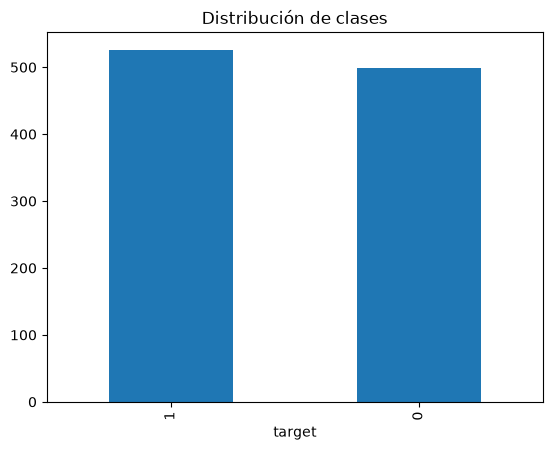

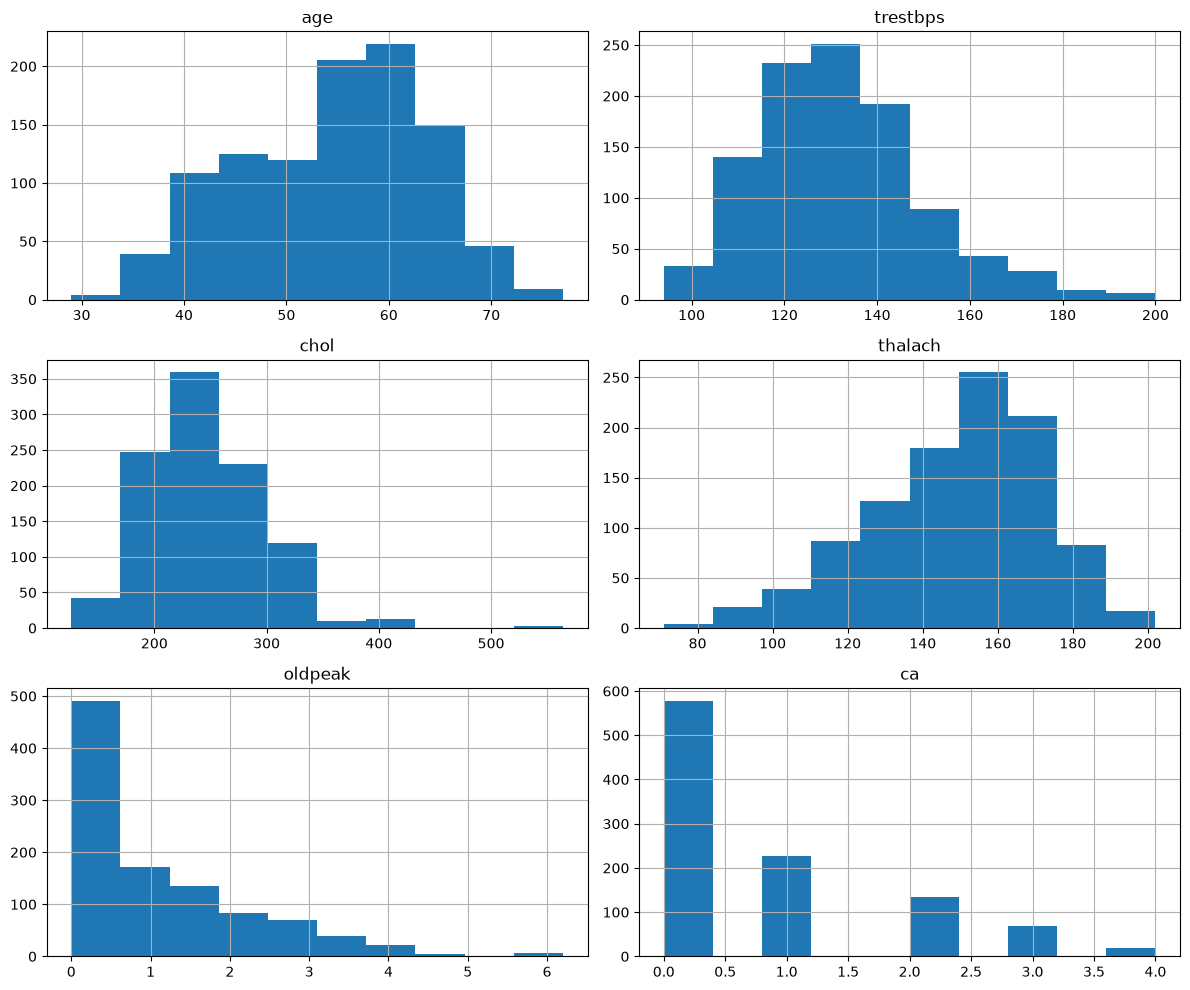

In [24]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.show()

df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Finalmente, se generó un gráfico de barras para visualizar la distribución de la variable objetivo (`target`), confirmando el balance descrito anteriormente entre pacientes con y sin enfermedad cardíaca. Adicionalmente, se generaron histogramas de todas las variables numéricas para observar su distribución general, lo cual es consistente con los valores mínimos, máximos y percentiles discutidos previamente mediante `df.describe()`.

Se verificó que la columna `target` ya se encuentra en formato binario en el dataset descargado (0 = ausencia de enfermedad, 1 = presencia de enfermedad), por lo que no fue necesario aplicar una transformación adicional de binarización.

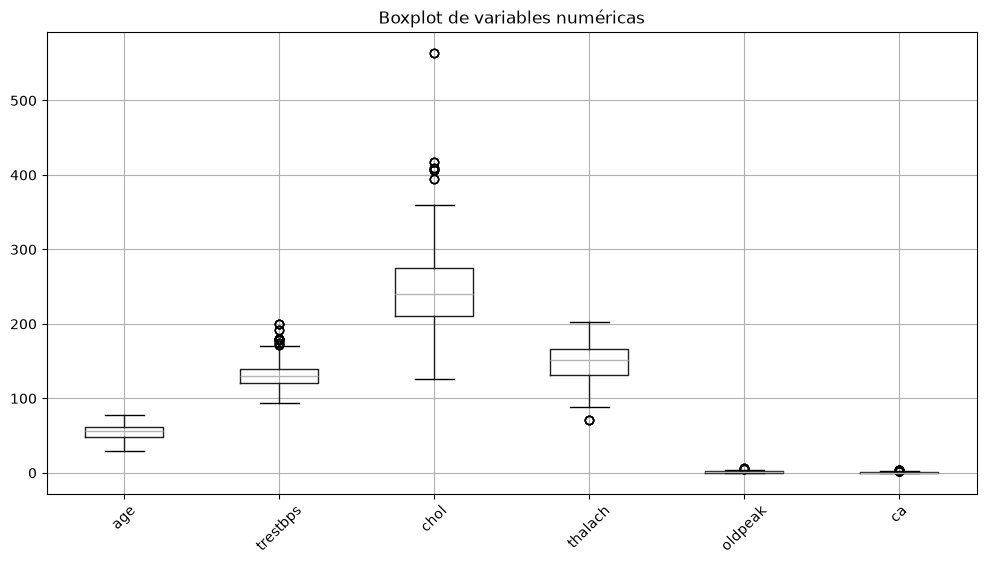

In [25]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

df[numeric_cols].boxplot(figsize=(12, 6))
plt.title("Boxplot de variables numéricas")
plt.xticks(rotation=45)
plt.show()

In [26]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    return outliers, limite_inferior, limite_superior

for col in numeric_cols:
    outliers, li, ls = detectar_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers | límites: [{li:.2f}, {ls:.2f}]")

age: 0 outliers | límites: [28.50, 80.50]
trestbps: 30 outliers | límites: [90.00, 170.00]
chol: 16 outliers | límites: [115.00, 371.00]
thalach: 4 outliers | límites: [81.00, 217.00]
oldpeak: 7 outliers | límites: [-2.70, 4.50]
ca: 87 outliers | límites: [-1.50, 2.50]


Se utilizó el método del rango intercuartílico (IQR) para identificar posibles valores atípicos en las variables numéricas. El análisis detectó posibles outliers principalmente en **oldpeak** y **ca**, seguidos por **trestbps y **chol**.

Estos valores no fueron eliminados automáticamente. La detección mediante IQR únicamente indica que determinadas observaciones se encuentran alejadas de la distribución central de los datos, pero no implica necesariamente que sean errores de medición. Debido a que se trata de variables clínicas y los valores observados pueden representar casos reales de pacientes, se decidió conservarlos para evitar perder información potencialmente relevante para el modelo.

### 1.3 Split 70/30 estratificado + normalización

In [29]:
from sklearn.model_selection import train_test_split

def feature_scale(X):
    """Standardize each feature to have mean 0 and standard deviation 1."""
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


features = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

X = df[features].values   # .values para convertir a array de NumPy
y = df["target"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Fit solo con train
X_train_scaled, X_means, X_stds = feature_scale(X_train)

# Transform con las mismas medias/desviaciones del train
X_test_scaled = (X_test - X_means) / X_stds

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Medias del train (deberían ser ~0):", X_train_scaled.mean(axis=0))
print("Desviaciones del train (deberían ser ~1):", X_train_scaled.std(axis=0))

Train shape: (717, 6)
Test shape: (308, 6)
Medias del train (deberían ser ~0): [-2.21115548e-16  9.46089635e-17  1.32235769e-16 -4.40140718e-17
 -6.71398471e-16 -4.30463042e-17]
Desviaciones del train (deberían ser ~1): [1. 1. 1. 1. 1. 1.]


Para realizar la división se utilizó ```train_test_split```, reservando el 70% de los datos para entrenamiento y el 30% para prueba. Se utilizó ```stratify=y``` para mantener aproximadamente la misma proporción entre pacientes con y sin enfermedad en ambos conjuntos.

Posteriormente, se estandarizaron las variables numéricas utilizando la media y desviación estándar calculadas únicamente sobre el conjunto de entrenamiento. Esta normalización es necesaria porque las características tienen escalas diferentes. Por ejemplo, ```age``` toma valores entre 29 y 77, mientras que ```chol``` toma valores entre 126 y 564. Sin normalización, las características con valores numéricamente mayores podrían afectar desproporcionadamente el proceso de descenso del gradiente.

### Selección de features
Se seleccionaron 6 features numéricas: age, trestbps, chol, thalach, oldpeak, ca. 

## 2. Implementar la regresión logística básica

### Regresión Logística

In [30]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))

def compute_cost(w, b, X, y):
    """Compute logistic regression cost J(w, b) using explicit model."""
    m, n = X.shape

    # For each example i: f_{w,b}^{(i)}(x^{(i)}) = sigmoid(w^T x^{(i)} + b)
    z = X @ w + b
    f = sigmoid(z)

    # Mathematically we use log(f) and log(1-f). In code, clip to avoid log(0).
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    return J

def compute_gradient(w, b, X, y):
    """Compute gradients dJ/dw and dJ/db with explicit model."""
    m, n = X.shape

    # f_{w,b}^{(i)}(x^{(i)})
    z = X @ w + b
    f = sigmoid(z)

    error = f - y  # e^{(i)} = f_{w,b}^{(i)}(x^{(i)}) - y^{(i)}

    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    """Run gradient descent to optimize w and b."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history


alpha = 0.01
num_iters = 1000

# Inicialización de parámetros
n_features = X_train_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

# Entrenamiento
w_final, b_final, J_history = gradient_descent(
    X_train_scaled, y_train, w_init, b_init, alpha, num_iters, print_every=100
)


Iteration    0: J(w, b) = 0.6916
Iteration  100: J(w, b) = 0.5943
Iteration  200: J(w, b) = 0.5525
Iteration  300: J(w, b) = 0.5313
Iteration  400: J(w, b) = 0.5191
Iteration  500: J(w, b) = 0.5115
Iteration  600: J(w, b) = 0.5064
Iteration  700: J(w, b) = 0.5028
Iteration  800: J(w, b) = 0.5001
Iteration  900: J(w, b) = 0.4981
Iteration  999: J(w, b) = 0.4966


El costo disminuye progresivamente a medida que aumentan las iteraciones, pasando de aproximadamente 0.6916 al inicio a 0.4966 después de 1000 iteraciones. Esto indica que el descenso del gradiente está ajustando los parámetros del modelo en una dirección que reduce la función de costo. La disminución es más pronunciada durante las primeras iteraciones y posteriormente se vuelve más gradual, lo que indica que el modelo se está acercando a una región de convergencia.


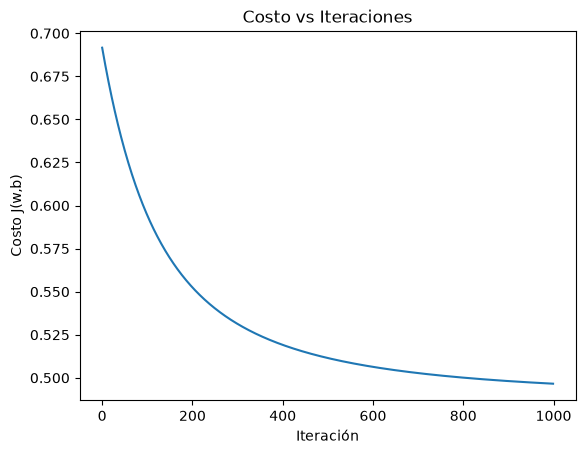

In [31]:
plt.plot(range(num_iters), J_history)
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Costo vs Iteraciones")
plt.show()

### Predicciones y métricas

In [32]:
def predict(X, w, b, threshold=0.5):
    z = X @ w + b
    f = sigmoid(z)
    return (f >= threshold).astype(int)

y_train_pred = predict(X_train_scaled, w_final, b_final)
y_test_pred = predict(X_test_scaled, w_final, b_final)

Si la probabilidad predicha es ≥ 0.5, se clasifica como 1 (enfermedad); si no, como 0.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, nombre=""):
    print(f"--- {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}\n")

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

--- Train ---
Accuracy:  0.7392
Precision: 0.7268
Recall:    0.7880
F1:        0.7562

--- Test ---
Accuracy:  0.7532
Precision: 0.7440
Recall:    0.7911
F1:        0.7669



El modelo obtuvo una exactitud de 73.92% en entrenamiento y 75.32% en prueba. Los resultados entre ambos conjuntos son similares, por lo que no se observa una diferencia significativa que sugiera un sobreajuste evidente.

El recall fue de 78.80% en entrenamiento y 79.11% en prueba, siendo la métrica más alta junto con el F1-score. Esto indica que el modelo logra identificar una proporción relativamente alta de los pacientes pertenecientes a la clase positiva.

### Coeficientes

In [35]:
for feature, coef in zip(features, w_final):
    print(f"{feature}: {coef:.4f}")
print(f"bias (b): {b_final:.4f}")

age: -0.0827
trestbps: -0.1906
chol: -0.1583
thalach: 0.6028
oldpeak: -0.6432
ca: -0.6061
bias (b): 0.0156


### Interpretación de Coeficientes


Al estar las variables normalizadas, los coeficientes indican la importancia de cada característica sobre la probabilidad de tener la enfermedad (clase 1):
* **Positivos:** Aumentan la probabilidad.
* **Negativos:** Disminuyen la probabilidad.

**Variables de mayor impacto (Factores decisivos):**
* `oldpeak` (-0.6432): Fuerte impacto *negativo* (reduce la probabilidad).
* `ca` (-0.6061): Fuerte impacto *negativo*.
* `thalach` (+0.6028): Fuerte impacto *positivo* (aumenta la probabilidad).

**Variables de menor impacto:**
* `trestbps` (-0.1906): Impacto negativo moderado.
* `chol` (-0.1583): Impacto negativo moderado.
* `age` (-0.0827): Impacto negativo débil.

Aunque `oldpeak`, `ca` y `thalach` dominan las predicciones, esto solo indica una asociación estadística dentro del modelo, no necesariamente una relación causal.

# 3. Visualize Decision Boundaries

In [36]:
def entrenar_par(df, feat1, feat2, target_col="target", alpha=0.01, num_iters=1000):
    X_pair = df[[feat1, feat2]].values.astype(float)
    y_pair = df[target_col].values.astype(float)

    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pair, y_pair, test_size=0.3, stratify=y_pair, random_state=42
    )

    # Normalizar (fit en train)
    X_tr_scaled, means, stds = feature_scale(X_tr)
    X_te_scaled = (X_te - means) / stds

    # Entrenar
    w_init = np.zeros(2)
    b_init = 0.0
    w, b, J_hist = gradient_descent(X_tr_scaled, y_tr, w_init, b_init, alpha, num_iters)

    return w, b, X_tr_scaled, y_tr, means, stds

In [37]:
def plot_decision_boundary(w, b, X, y, feat1_name, feat2_name):
    plt.figure(figsize=(7, 6))

    # Puntos reales, coloreados por clase
    plt.scatter(X[y==0, 0], X[y==0, 1], c="red", label="Sin enfermedad (0)", alpha=0.6)
    plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", label="Con enfermedad (1)", alpha=0.6)

    # Línea de decisión: w0*x1 + w1*x2 + b = 0  →  x2 = -(w0*x1 + b) / w1
    x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    x2_vals = -(w[0] * x1_vals + b) / w[1]
    plt.plot(x1_vals, x2_vals, color="black", linewidth=2, label="Frontera de decisión")

    plt.xlabel(f"{feat1_name} (normalizado)")
    plt.ylabel(f"{feat2_name} (normalizado)")
    plt.title(f"Frontera de decisión: {feat1_name} vs {feat2_name}")
    plt.legend()
    plt.show()

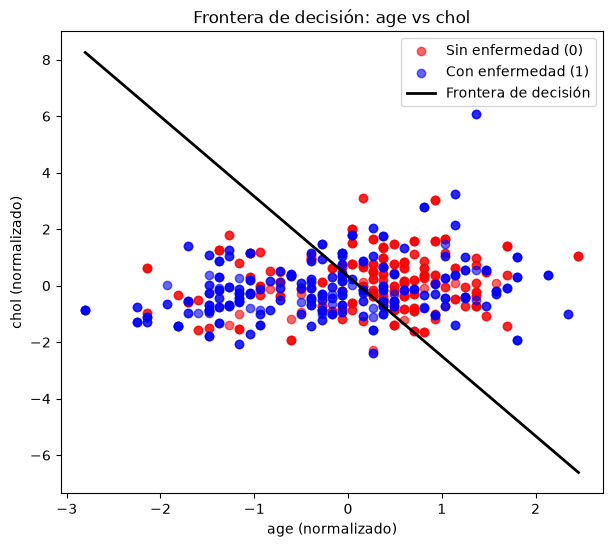

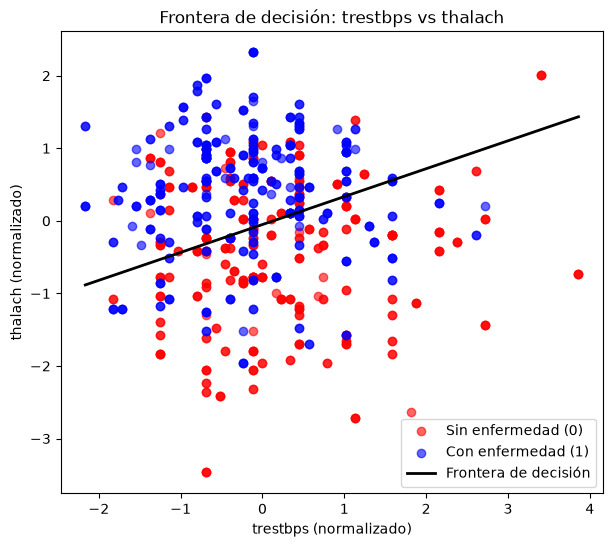

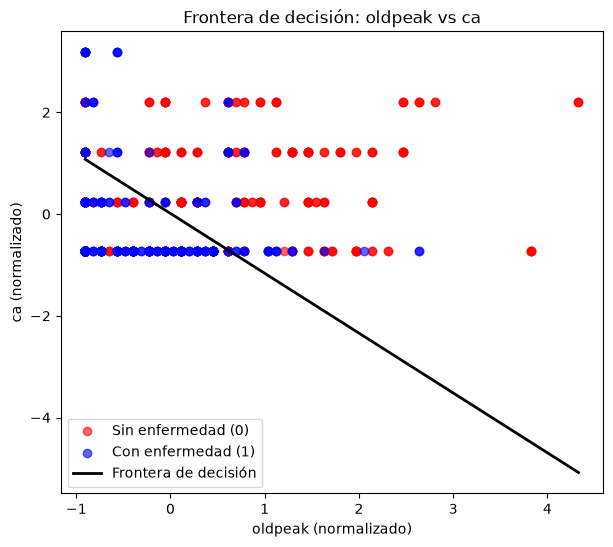

In [38]:
pares = [
    ("age", "chol"),
    ("trestbps", "thalach"),
    ("oldpeak", "ca"),
]

for feat1, feat2 in pares:
    w, b, X_scaled, y_tr, means, stds = entrenar_par(df, feat1, feat2)
    plot_decision_boundary(w, b, X_scaled, y_tr, feat1, feat2)

### Interpretación de las fronteras de decisión

**Age vs Chol:**  
Se observa una gran superposición entre los pacientes con y sin enfermedad. La frontera de decisión permite realizar una separación aproximada, pero estas dos variables por sí solas no permiten clasificar claramente las dos clases.

**Trestbps vs Thalach:**  
También existe una considerable superposición entre ambas clases. La frontera lineal consigue separar parcialmente los datos, aunque varios pacientes de ambas clases quedan a ambos lados de la frontera.

**Oldpeak vs Ca:**  
Los datos presentan una distribución diferente debido a que `ca` tiene pocos valores posibles, formando grupos horizontales. Aunque la frontera permite una separación parcial, todavía existe una importante superposición entre las clases.

En general, las tres gráficas muestran que una frontera lineal basada únicamente en dos características no es suficiente para separar perfectamente a los pacientes con y sin enfermedad. Esto justifica utilizar varias características simultáneamente en el modelo.

# 4. 

In [39]:
def compute_cost_reg(w, b, X, y, lambda_=0):
    """Compute logistic regression cost with L2 regularization."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)

    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    cost = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )

    # Término de regularización L2 (no se regulariza el bias b)
    reg_term = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return cost + reg_term


def compute_gradient_reg(w, b, X, y, lambda_=0):
    """Compute gradients with L2 regularization."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    error = f - y

    dj_dw = (1 / m) * (X.T @ error) + (lambda_ / m) * w
    dj_db = (1 / m) * np.sum(error)  # el bias NO se regulariza

    return dj_dw, dj_db

In [40]:
def gradient_descent_reg(X, y, w_init, b_init, alpha, num_iters, lambda_=0, print_every=0):
    """Run gradient descent with L2 regularization."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_reg(w, b, X, y, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost_reg(w, b, X, y, lambda_)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history

In [41]:
lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 50, 100]
resultados = []

for lam in lambdas:
    w_init = np.zeros(n_features)
    b_init = 0.0

    w_lam, b_lam, J_hist_lam = gradient_descent_reg(
        X_train_scaled, y_train, w_init, b_init, alpha, num_iters, lambda_=lam
    )

    y_train_pred_lam = predict(X_train_scaled, w_lam, b_lam)
    y_test_pred_lam = predict(X_test_scaled, w_lam, b_lam)

    resultados.append({
        "lambda": lam,
        "train_acc": accuracy_score(y_train, y_train_pred_lam),
        "test_acc": accuracy_score(y_test, y_test_pred_lam),
        "train_f1": f1_score(y_train, y_train_pred_lam),
        "test_f1": f1_score(y_test, y_test_pred_lam),
        "norma_w": np.linalg.norm(w_lam),
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,lambda,train_acc,test_acc,train_f1,test_f1,norma_w
0,0.000,0.739191,0.753247,0.756193,0.766871,1.101238
1,0.001,0.739191,0.753247,0.756193,0.766871,1.101232
2,0.010,0.739191,0.753247,0.756193,0.766871,1.101182
3,0.100,0.739191,0.753247,0.756193,0.766871,1.100678
4,1.000,0.739191,0.753247,0.756193,0.766871,1.095661
5,10.000,0.739191,0.753247,0.756193,0.766871,1.047904
6,50.000,0.740586,0.750000,0.758442,0.765957,0.878701
7,100.000,0.740586,0.756494,0.760309,0.774775,0.734064


Primero se utilizó el rango `lambdas = [0, 0.001, 0.01, 0.1, 1]`, pero lamentablemente los resultados salieron todos idénticos entre sí. Por lo que se decidió ampliar ese rango a `lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 50, 100]`, donde sí empezó a notarse la caída de los pesos y una leve degradación en las métricas.

In [46]:
def entrenar_par_reg(df, feat1, feat2, lambda_=0, target_col="target", alpha=0.01, num_iters=1000):
    X_pair = df[[feat1, feat2]].values.astype(float)
    y_pair = df[target_col].values.astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pair, y_pair, test_size=0.3, stratify=y_pair, random_state=42
    )

    X_tr_scaled, means, stds = feature_scale(X_tr)
    X_te_scaled = (X_te - means) / stds

    w_init = np.zeros(2)
    b_init = 0.0
    w, b, J_hist = gradient_descent_reg(
        X_tr_scaled, y_tr, w_init, b_init, alpha, num_iters, lambda_=lambda_
    )

    return w, b, X_tr_scaled, y_tr, J_hist

In [47]:
w_sin_reg, b_sin_reg, X_scaled_pair, y_pair_tr, J_sin_reg = entrenar_par_reg(
    df, "oldpeak", "ca", lambda_=0
)

w_con_reg, b_con_reg, _, _, J_con_reg = entrenar_par_reg(
    df, "oldpeak", "ca", lambda_=100
)

print("Pesos sin regularizar:", w_sin_reg, "| norma:", np.linalg.norm(w_sin_reg))
print("Pesos con regularizar:", w_con_reg, "| norma:", np.linalg.norm(w_con_reg))

Pesos sin regularizar: [-0.8055191  -0.68479677] | norma: 1.0572642215824042
Pesos con regularizar: [-0.51687344 -0.45063761] | norma: 0.6857349396206318


Al comparar directamente los pesos del par `oldpeak`–`ca`, se observó una reducción clara en la norma de los pesos al aplicar regularización: de 1.0573 (λ=0) a 0.6857 (λ=100), una disminución de aproximadamente 35%. Sin embargo, dado que ambos pesos se redujeron de forma proporcional, la pendiente relativa entre las dos variables se mantuvo similar, lo cual explica por qué la frontera de decisión graficada no mostró un cambio visual significativo entre ambos modelos.

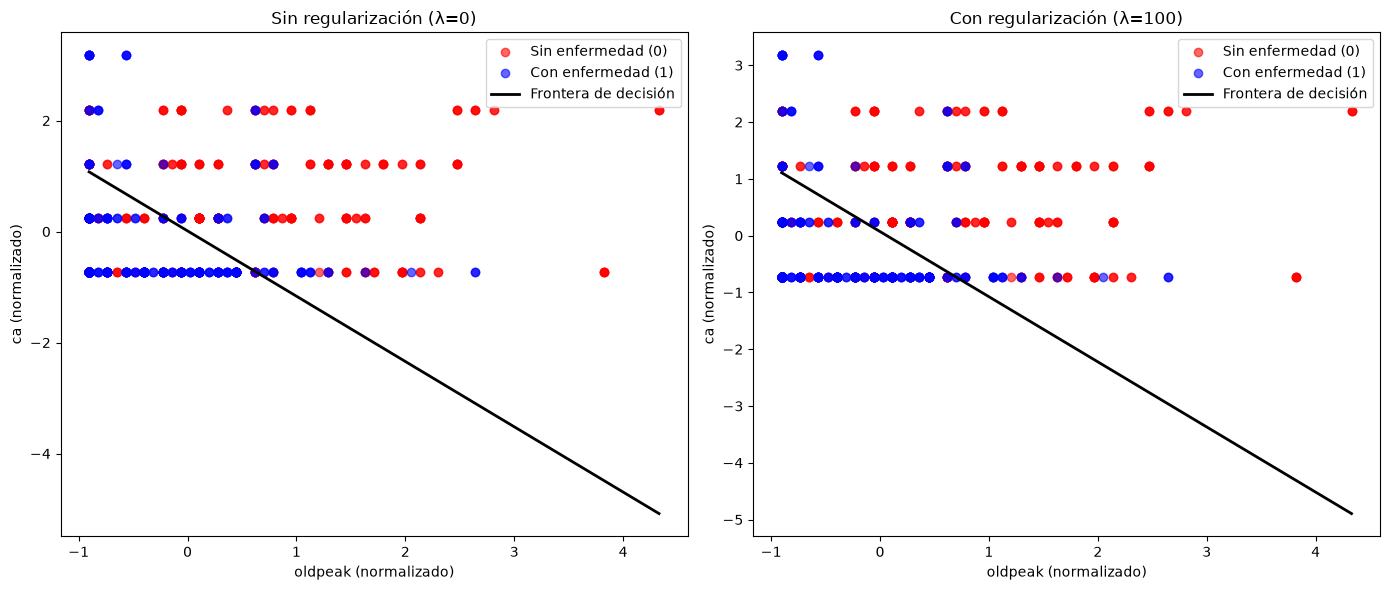

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, w, b, titulo in zip(
    axes, [w_sin_reg, w_con_reg], [b_sin_reg, b_con_reg],
    ["Sin regularización (λ=0)", "Con regularización (λ=100)"]
):
    ax.scatter(X_scaled_pair[y_pair_tr==0, 0], X_scaled_pair[y_pair_tr==0, 1],
               c="red", label="Sin enfermedad (0)", alpha=0.6)
    ax.scatter(X_scaled_pair[y_pair_tr==1, 0], X_scaled_pair[y_pair_tr==1, 1],
               c="blue", label="Con enfermedad (1)", alpha=0.6)

    x1_vals = np.linspace(X_scaled_pair[:,0].min(), X_scaled_pair[:,0].max(), 100)
    x2_vals = -(w[0] * x1_vals + b) / w[1]
    ax.plot(x1_vals, x2_vals, color="black", linewidth=2, label="Frontera de decisión")

    ax.set_xlabel("oldpeak (normalizado)")
    ax.set_ylabel("ca (normalizado)")
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

Se compararon las fronteras de decisión del par `oldpeak`–`ca` entrenadas sin regularización (λ=0) y con regularización fuerte (λ=100). Aunque la norma de los pesos se redujo de 1.0573 a 0.6857, la frontera de decisión resultante es visualmente casi idéntica entre ambos modelos. Esto se debe a que la reducción de los pesos fue proporcional entre `oldpeak` y `ca`, manteniendo su relación relativa y, por lo tanto, la pendiente e intercepto de la frontera prácticamente no cambiaron. Este resultado refuerza que, en este caso, la regularización reduce la magnitud de los pesos sin alterar significativamente el comportamiento del modelo, ya que no existía overfitting que corregir.

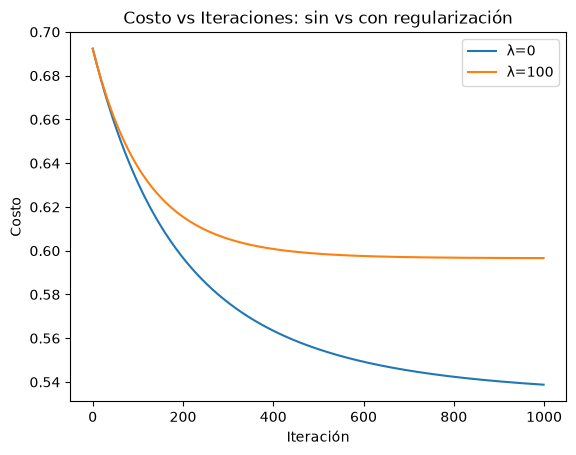

In [45]:
plt.plot(J_sin_reg, label="λ=0")
plt.plot(J_con_reg, label="λ=100")
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Costo vs Iteraciones: sin vs con regularización")
plt.legend()
plt.show()

La gráfica de costo vs iteraciones para el par `oldpeak`–`ca` confirma el mismo patrón observado en el modelo completo: el modelo sin regularizar (λ=0) converge a un costo menor (~0.54) que el modelo regularizado (λ=100), el cual se estabiliza en un valor más alto (~0.60). Esta diferencia se debe a que el costo regularizado incluye el término de penalización λ/(2m)||w||², que se suma al costo original independientemente de qué tan bien ajuste el modelo los datos, elevando el costo final del modelo con λ=100 aunque ambos modelos logren fronteras de decisión prácticamente equivalentes, como se observó en la gráfica anterior.